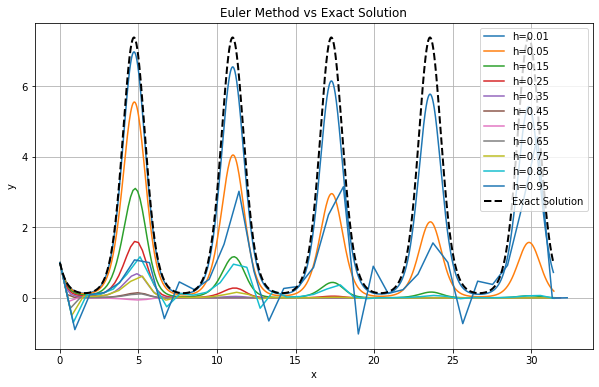

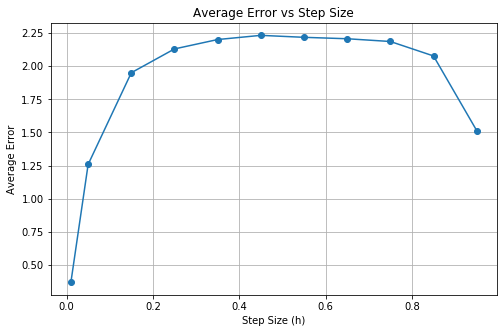

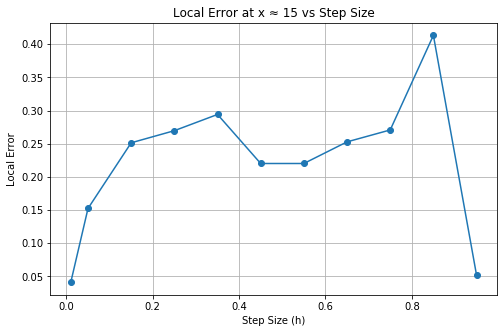

In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.ion()

def y_exact(x):
    return np.exp(-2*np.sin(x))

def euler(h):
    x_vals = np.arange(0, 10*np.pi + h, h)
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = 1

    for i in range(len(x_vals) - 1):
        y_vals[i+1] = y_vals[i] + h * (-2 * y_vals[i] * np.cos(x_vals[i]))

    return x_vals, y_vals

h_values = [0.01, 0.05] + list(np.arange(0.15, 1.01, 0.1))

avg_errors = []
local_errors = []

plt.figure(figsize=(10,6))

for h in h_values:
    x, y = euler(h)
    y_true = y_exact(x)

    plt.plot(x, y, label=f"h={h:.2f}")

    avg_error = np.mean(np.abs(y - y_true))
    avg_errors.append(avg_error)

    idx = np.argmin(np.abs(x - 15))
    local_error = abs(y[idx] - y_exact(x[idx]))
    local_errors.append(local_error)

x_exact = np.linspace(0, 10*np.pi, 2000)
plt.plot(x_exact, y_exact(x_exact), 'k--', linewidth=2, label="Exact Solution")

plt.title("Euler Method vs Exact Solution")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.savefig("plot1_euler_vs_exact.png")  
plt.show()

plt.figure(figsize=(8,5))

plt.plot(h_values, avg_errors, marker='o')

plt.title("Average Error vs Step Size")
plt.xlabel("Step Size (h)")
plt.ylabel("Average Error")
plt.grid()

plt.savefig("plot2_avg_error.png")
plt.show()

plt.figure(figsize=(8,5))

plt.plot(h_values, local_errors, marker='o')

plt.title("Local Error at x ≈ 15 vs Step Size")
plt.xlabel("Step Size (h)")
plt.ylabel("Local Error")
plt.grid()

plt.savefig("plot3_local_error.png") 
plt.show()

# Short Explanation
Euler's method was used to approximate the solution to the differential equation dy/dx=-2ycos(x) over the interval [0,10pi] for various step sizes h. The numerical results were compared to the solution y(x)=e-2sin(x).

From the first plot, smaller step sizes produce solutions that closely match the exact solution, while larger step sizes lead to noticeable deviations. This occurs because Euler's method approximates the slope using a linear estimate, which becomes less accurate over larger steps. 

The second plot shows that the average error increases as the step size increases. This confirms that Euler’s method is a first-order method, meaning the error is proportional to h.

The third plot demonstrates that the local error near x≈15 also increases with step size. This highlights how numerical error accumulates as the solution progresses.

Overall, smaller step sizes improve accuracy but require more computation, while larger step sizes reduce computation but introduce significant error.